In [160]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        
os.makedirs("outputs", exist_ok=True)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datas

**###Part 1: Warmup Exercises###**



**PyTorch Tensors******

**Tensor Question 1**

In [161]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)
## a
print(f'a value: \n {a}')

print()
print(f'shape a: \n {a.shape}')
print()
print(f'dtype a: \n {a.dtype}')
print(f'device a: \n {a.device}')
print()
## b
print(f'b value: \n {b}')
print()
print(f'shape: \n {b.shape}')
print()
print(f'dtype b: \n {b.dtype}')
print(f'device b: \n {b.device}')
##c
print(f'c value: \n {c}')
print()
print(f'shape c: \n {c.shape}')
print()
print(f'dtype c: \n {c.dtype}')
print(f'device c: \n {c.device}')

a value: 
 tensor([[1., 2., 3.],
        [4., 5., 6.]])

shape a: 
 torch.Size([2, 3])

dtype a: 
 torch.float32
device a: 
 cpu

b value: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

shape: 
 torch.Size([2, 3])

dtype b: 
 torch.float32
device b: 
 cpu
c value: 
 tensor([1., 1., 1., 1.])

shape c: 
 torch.Size([4])

dtype c: 
 torch.float32
device c: 
 cpu


## ****Comment##

All tensors are located on the cpu. In a training loop on GPU, both model weights and input tensors must be on the same device, otherwise PyTorch will raise a runtime error.

**##Tensor Question 2**

In [162]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

#Compute and print the element-wise square root using torch.sqrt().

print("sqrt:", torch.sqrt(x))

#Compute and print the sum using .sum().
print("sum:", x.sum())

#Compute and print the mean using .mean().
print("mean:", x.mean())

#Find and print the index of the maximum value using .argmax().
print("argmax:", x.argmax())



sqrt: tensor([1., 2., 3., 4., 5.])
sum: tensor(55.)
mean: tensor(11.)
argmax: tensor(4)


# **Comment: .argmax() returns the index of the largest value. In a classifier with 1000 outputs, it gives the index of the predicted class with the highest score.

**Tensor Question 3**

In [163]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


**Comment:** NumPy works only on CPU. If the tensor is on GPU, we must move it back to CPU before using .numpy().

**Tensor Question 4:**


In [164]:
t = torch.arange(24).float()
print(t)

#Reshape t to (4, 6) and print the shape.
t1 = t.reshape(4, 6)
print("Shape (4,6):", t1.shape)

#Reshape t to (2, 3, 4) and print the shape.
t2 = t.reshape(2, 3, 4)
print("Shape (2,3,4):", t2.shape)

#Take your result from step 1 and add a new dimension at position 0. Print the new shape.
t3 = t1.unsqueeze(0)
print("Shape after unsqueeze:", t3.shape)


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
Shape (4,6): torch.Size([4, 6])
Shape (2,3,4): torch.Size([2, 3, 4])
Shape after unsqueeze: torch.Size([1, 4, 6])


**Comment:** unsqueeze(0) adds one extra dimension at the beginning. Neural networks expect data in batches, so for one image we make it look like a batch of size 1.

**Tensor Question 5**

In [165]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

#Compute the matrix product using NumPy and print the result.
np_result = np.matmul(np_a, np_b)
print("NumPy result:\n", np_result)

#Compute the same product using PyTorch and print the result.
torch_result = torch.matmul(t_a, t_b)
print("PyTorch result:\n", torch_result)



NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])


**Comment:** Matrix multiplication is the core operation in neural networks. Each layer multiplies input data by weights to produce outputs.

**Pretrained Models**

**Model Question 1**

In [166]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")




Total parameters:     11,689,512
Trainable parameters: 11,689,512


**Comment**: Pretrained models save huge amounts of time and compute. Instead of training on millions of images, we can reuse learned features and apply them directly.

**Model Question 2**

In [167]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

****Comments: ****
 the name of the final layer in ResNet18 is  (fc): Linear(in_features=512, out_features=1000, bias=True)
 The output size is 1000 (This number is the total count of ImageNet categories the model can predict.)

 layer1 to layer4 are feature extraction layers. They learn from simple features like edges to complex features like objects. A network is called deep because it has many layers that learn step by step

**Model Question 3**

In [168]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


****What does .to(device) do, and why does it need to match the device your input tensors will be on?

.to(device) moves the model to CPU or GPU.
What does model.eval() change about the model's behavior? Name at least one layer type that behaves differently in training mode vs. evaluation mode.
model.eval() switches the model to evaluation mode, disabling dropout and fixing batch normalization behavior.

**Model Question 4**

In [169]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


What does the resize/crop step accomplish?
Resize and crop ensure images match the input size expected by the model.

What does ToTensor() do to the pixel value range?
ToTensor() converts pixel values to [0,1].

What is normalization doing, and why does it use ImageNet's specific mean and standard deviation values rather than, say, mean=0.5, std=0.5?
Normalization uses ImageNet mean and std so inputs match the distribution the model was trained on.

**Running Inference**

In [170]:
import random
random.seed(42)

#DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
#DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test")
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


**Inference Question 1**

In [171]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.no_grad():
        output = model(input_tensor)
      # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    probs = torch.nn.functional.softmax(output[0], dim=0)
      # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)

    top_probs, top_indices = torch.topk(probs, 5)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))

    return results


img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"{class_name:30s} {prob:.4f}")

  

  
    


Top-5 predictions for '24204.jpg':
alp                            0.4911
volcano                        0.2076
valley                         0.2016
promontory                     0.0184
mountain tent                  0.0169


# The top prediction makes sense. The model predicted "alp" with the highest #probability,
# which refers to a mountain landscape. Other predictions like "volcano" and "valley"
# are also related to mountains. Even though the model does not have a "mountain" class,
# it still correctly identifies similar categories from ImageNet.

**Inference Question 2**

In [172]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


The model is more confident on clear natural scenes (like sea or forest) and less confident on complex or mixed scenes like buildings or streets.

**Inference Question 3**

In [173]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


**Comment:**

Neural networks output logits instead of probabilities because logits are easier and more stable for training. They can take any value (negative or positive), which gives the model more flexibility when learning.

Probabilities are created using softmax, but doing this too early can cause numerical issues and slow down training.

In a production system, I would use probabilities (after softmax) to filter low-confidence predictions, because they are easier to understand (values between 0 and 1 that sum to 1). For example, I can set a rule like “only accept predictions with probability > 0.8”.

**Inference Question 4**

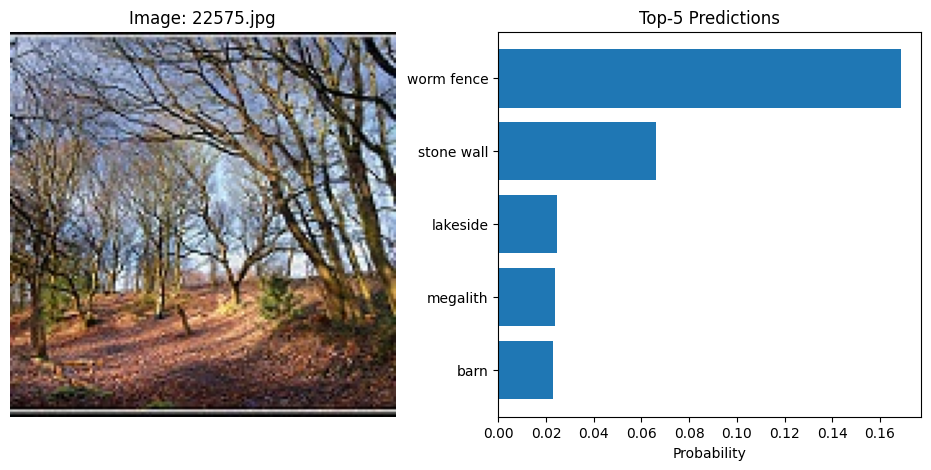

In [174]:
# Running inference on one image
img, img_name = load_sample_image("forest")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

# Split predictions into labels and probabilities
labels = [p[0] for p in preds]
probs = [p[1] for p in preds]

# Creating figure with 2 panels
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Left : image

ax[0].imshow(img)
ax[0].axis("off")
ax[0].set_title(f"Image: {img_name}")


# Right : bar chart

y_pos = np.arange(len(labels))

ax[1].barh(y_pos, probs)
ax[1].set_yticks(y_pos)
ax[1].set_yticklabels(labels)
ax[1].invert_yaxis()  # highest at top
ax[1].set_xlabel("Probability")
ax[1].set_title("Top-5 Predictions")

# Saving the output
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/warmup_inference_viz.png", bbox_inches="tight")

plt.show()

**Comment:**

This visualization shows the input image alongside the model’s top-5 predictions. It helps quickly understand whether the model is confident and whether its predictions match the visual content.
In a real dashboard, I would use a threshold (for example 0.7 or 0.8 on top-1 probability) to decide whether to automatically accept a prediction or flag it for human review. If confidence is low, the prediction should not be trusted.